<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/EarlyFusionCNN_Optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
# print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)


True
Using device: cuda


In [ ]:
# print(next(ts_model.parameters()).is_cuda)
# unique, counts = torch.unique(y_ts_tensor, return_counts=True)
# for cls, cnt in zip(unique.tolist(), counts.tolist()):
#     print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")

In [ ]:
import pandas as pd

ECG_data_1K = np.load('ECG_waveforms_10K.npy')
Echo_5K = pd.read_csv('echonext_metadata_100k.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1

#initial definitions - ECGs
y_ts = np.array(labels[:10000])
X = ECG_data_1K[:10000]
X_ts = np.swapaxes(X, 1, 2)
# print(X_ts.shape)
# print(y_ts.shape)

#initial definitions - metrics
y_metric = np.array(labels[:10000])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:10000])
# print(demog_metric[50])





(10000, 12, 2500)
(10000,)
[64 'male' 'white' 77.0 77.0 156.0 76.0 405.0]



## 14. Train the 1D CNN


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# ─────────────────────────────────────────────
# 0.  Device
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# 1.  Demographic pre-processing
# ─────────────────────────────────────────────
CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected"
]

ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS


def preprocess_demographics(
    df:     pd.DataFrame,
    scaler: StandardScaler = None,
    knn_k:  int = 5,
    fit:    bool = True,
) -> tuple[np.ndarray, StandardScaler, list[str]]:
    """
    Returns
    -------
    demo_array    : float32 array, shape (N, demo_dim)
    scaler        : fitted StandardScaler  (reuse at inference)
    feature_names : column names after OHE (useful for inspection)
    """
    df = df[ALL_DEMO_COLS].copy()

    # ── KNN imputation ────────────────────────────────────────────────────
    cat_codes = df[CATEGORICAL_COLS].apply(
        lambda col: col.astype("category").cat.codes.replace(-1, np.nan)
    )
    cont_part     = df[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    imputer = KNNImputer(n_neighbors=knn_k)
    imputed = imputer.fit_transform(imputer_input)   # stateless; fine per-call
    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df.index)

    # Decode categorical codes back to string labels
    for col in CATEGORICAL_COLS:
        original_cats = df[col].astype("category").cat.categories
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = original_cats[codes_rounded].values

    # ── One-hot encode ────────────────────────────────────────────────────
    ohe_df        = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)
    feature_names = list(ohe_df.columns)

    # ── Standardise continuous columns ────────────────────────────────────
    if scaler is None:
        scaler = StandardScaler()
    cont_indices = [feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)
    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, feature_names


# ─────────────────────────────────────────────
# 2.  Dataset & DataLoaders
# ─────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts: np.ndarray, X_demo: np.ndarray, y: np.ndarray):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]


def build_loaders(
    X_ts:        np.ndarray,
    X_demo:      np.ndarray,
    y:           np.ndarray,
    train_frac:  float = 0.8,
    batch_train: int   = 32,
    batch_test:  int   = 128,
    seed:        int   = 42,
):
    dataset    = FusedDataset(X_ts, X_demo, y)
    train_size = int(train_frac * len(dataset))
    test_size  = len(dataset) - train_size
    train_ds, test_ds = random_split(
        dataset, [train_size, test_size],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_train, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_test,  shuffle=False)

    # print(f"Training samples : {len(train_ds)}")
    # print(f"Test samples     : {len(test_ds)}")
    # print(f"Demo feature dim : {X_demo.shape[1]}")
    wv, dm, lb = next(iter(train_loader))
    # print(f"Batch waveform   : {wv.shape}")
    # print(f"Batch demo       : {dm.shape}")

    return train_loader, test_loader


# ─────────────────────────────────────────────
# 3.  FiLM conditioning layer
# ─────────────────────────────────────────────
class FiLMLayer(nn.Module):


    def __init__(self, demo_embed_dim: int, num_channels: int):
        super().__init__()
        # Projects shared demo embedding → 2 × num_channels scalars (γ and β)
        self.film_proj = nn.Linear(demo_embed_dim, 2 * num_channels)
        self.num_channels = num_channels

        nn.init.zeros_(self.film_proj.weight)
        nn.init.zeros_(self.film_proj.bias)
        with torch.no_grad():
            self.film_proj.bias[:num_channels] = 1.0

    def forward(self, h: torch.Tensor, demo_embed: torch.Tensor) -> torch.Tensor:

        params = self.film_proj(demo_embed)           # (B, 2C)
        gamma, beta = params.chunk(2, dim=-1)         # each (B, C)
        gamma = gamma.unsqueeze(-1)                   # (B, C, 1)
        beta  = beta.unsqueeze(-1)                    # (B, C, 1)
        return gamma * h + beta                       # broadcast over L


# ─────────────────────────────────────────────
# 4.  FiLM-conditioned CNN block
# ─────────────────────────────────────────────
class FiLMConvBlock(nn.Module):


    def __init__(
        self,
        in_channels:    int,
        out_channels:   int,
        kernel_size:    int,
        padding:        int,
        pool_size:      int,
        dropout:        float,
        demo_embed_dim: int,
    ):
        super().__init__()
        self.conv    = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding)
        self.film    = FiLMLayer(demo_embed_dim, out_channels)
        self.act     = nn.ReLU()
        self.drop    = nn.Dropout(dropout)
        self.pool    = nn.AvgPool1d(kernel_size=pool_size)

    def forward(self, x: torch.Tensor, demo_embed: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)           # (B, out_channels, L)
        x = self.film(x, demo_embed)   # modulate with demographics
        x = self.act(x)
        x = self.drop(x)
        x = self.pool(x)
        return x


# ─────────────────────────────────────────────
# 5.  Full model
# ─────────────────────────────────────────────
class HeartDiseaseNet(nn.Module):

    def __init__(
        self,
        sequence_length: int = 2500,
        in_channels:     int = 12,
        demo_dim:        int = 20,    # set after preprocessing
        num_classes:     int = 2,
        demo_embed_dim:  int = 32,    # shared demographic embedding size
    ):
        super().__init__()

        # ── Demographic encoder (shared; feeds all FiLM layers) ───────────
        self.demo_encoder = nn.Sequential(
            nn.Linear(demo_dim, demo_embed_dim),
            nn.ReLU(),
        )

        # ── FiLM-conditioned conv blocks ──────────────────────────────────
        self.block1 = FiLMConvBlock(in_channels, 4,  kernel_size=15, padding=7,  pool_size=5, dropout=0.20, demo_embed_dim=demo_embed_dim)
        self.block2 = FiLMConvBlock(4,           8,  kernel_size=9,  padding=4,  pool_size=5, dropout=0.40, demo_embed_dim=demo_embed_dim)
        self.block3 = FiLMConvBlock(8,           12, kernel_size=5,  padding=2,  pool_size=5, dropout=0.40, demo_embed_dim=demo_embed_dim)
        self.block4 = FiLMConvBlock(12,          16, kernel_size=3,  padding=2,  pool_size=5, dropout=0.30, demo_embed_dim=demo_embed_dim)


        # ── Dynamically compute flattened size ────────────────────────────
        with torch.no_grad():
            dummy_ts   = torch.zeros(1, in_channels, sequence_length)
            dummy_demo = torch.zeros(1, demo_embed_dim)   # already embedded
            x = self.block1(dummy_ts,   dummy_demo)
            x = self.block2(x,          dummy_demo)
            x = self.block3(x,          dummy_demo)
            x = self.block4(x,          dummy_demo)
            flat_sz = x.shape[1] * x.shape[2]
        # print(f"Flattened size after FiLM-CNN blocks: {flat_sz}")

        # ── Classification head ───────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_sz, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x_ts: torch.Tensor, x_demo: torch.Tensor) -> torch.Tensor:

        demo_embed = self.demo_encoder(x_demo)   # (B, demo_embed_dim)

        x = self.block1(x_ts, demo_embed)
        x = self.block2(x,    demo_embed)
        x = self.block3(x,    demo_embed)
        x = self.block4(x,    demo_embed)

        return self.head(x)                      # (B, num_classes)


# ─────────────────────────────────────────────
# 6.  Training & evaluation
# ─────────────────────────────────────────────
def evaluate_classifier(model, data_loader, criterion=None):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in data_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            logits      = model(X_ts_b, X_demo_b)
            loss        = criterion(logits, y_b)
            b           = X_ts_b.shape[0]
            total_loss += loss.item() * b
            correct    += (torch.argmax(logits, dim=1) == y_b).sum().item()
            total      += b
    return total_loss / total, correct / total


def train_classifier(
    model,
    train_loader,
    test_loader   = None,
    epochs        = 50,
    learning_rate = 1e-3,
    verbose       = True,
):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=2e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

            b           = X_ts_b.shape[0]
            total_loss += loss.item() * b
            correct    += (torch.argmax(logits, dim=1) == y_b).sum().item()
            total      += b

        scheduler.step()
        train_loss = total_loss / total
        train_acc  = correct   / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
        #     if verbose:
        #         print(
        #             f"Epoch {epoch+1}/{epochs}: "
        #             f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
        #             f"test loss={test_loss:.4f},  test acc={test_acc:.4f}, "
        #             f"lr={optimizer.param_groups[0]['lr']:.2e}"
        #         )
        # else:
        #     if verbose:
        #         print(
        #             f"Epoch {epoch+1}/{epochs}: "
        #             f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
        #             f"lr={optimizer.param_groups[0]['lr']:.2e}"
        #         )

    return history


# ─────────────────────────────────────────────
# 7.  Example usage  (replace with real data)
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # Use the pre-loaded data (ECG_data_1K, Echo_5K, labels) instead of generating random data
    N = len(y_ts) # Get N from the actual data length

    # Prepare demographic DataFrame from Echo_5K
    # Ensure the column names match ALL_DEMO_COLS used in preprocess_demographics
    demo_df = Echo_5K[ALL_DEMO_COLS].iloc[:N].copy()

    # It's good practice to handle potential missing values explicitly before preprocessing,
    # or ensure preprocess_demographics can handle them robustly.
    # The preprocess_demographics already includes KNN imputation, so we can proceed.

    # Preprocess the actual demographic data
    demog_metrics_processed, scaler, feature_names = preprocess_demographics(demo_df, fit=True)
    demo_dim = demog_metrics_processed.shape[1]
    # print(f"\nDemo features ({demo_dim}): {feature_names}\n")


    # Build DataLoaders using the loaded X_ts, y_ts, and the preprocessed demographics
    train_loader, test_loader = build_loaders(
        X_ts, demog_metrics_processed, y_ts, train_frac=0.8, batch_train=32, batch_test=128
    )

    model = HeartDiseaseNet(
        sequence_length = X_ts.shape[2], # Use actual sequence length
        in_channels     = X_ts.shape[1], # Use actual number of channels
        demo_dim        = demo_dim,
        num_classes     = 2,
        demo_embed_dim  = 32,
    )
    # print(model)

    history = train_classifier(
        model, train_loader, test_loader=test_loader, epochs=40, learning_rate=5e-4
    )

Using device: cuda

Demo features (14): ['age_at_ecg', 'ventricular_rate', 'atrial_rate', 'pr_interval', 'qrs_duration', 'qt_corrected', 'race_ethnicity_asian', 'race_ethnicity_black', 'race_ethnicity_hispanic', 'race_ethnicity_other', 'race_ethnicity_unknown', 'race_ethnicity_white', 'sex_female', 'sex_male']

Training samples : 8000
Test samples     : 2000
Demo feature dim : 14
Batch waveform   : torch.Size([32, 12, 2500])
Batch demo       : torch.Size([32, 14])
Flattened size after FiLM-CNN blocks: 64
HeartDiseaseNet(
  (demo_encoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
  )
  (block1): FiLMConvBlock(
    (conv): Conv1d(12, 4, kernel_size=(15,), stride=(1,), padding=(7,))
    (film): FiLMLayer(
      (film_proj): Linear(in_features=32, out_features=8, bias=True)
    )
    (act): ReLU()
    (drop): Dropout(p=0.2, inplace=False)
    (pool): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (block2): FiLMConvBlock(
    (con

In [ ]:


import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)


def expected_calibration_error(y_true, y_prob, n_bins=10):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n_total = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        # include right edge on the last bin
        if i == n_bins - 1:
            in_bin = (y_prob >= lo) & (y_prob <= hi)
        else:
            in_bin = (y_prob >= lo) & (y_prob < hi)

        n_bin = in_bin.sum()
        if n_bin == 0:
            continue

        acc_bin        = y_true[in_bin].mean()
        confidence_bin = y_prob[in_bin].mean()
        ece           += (n_bin / n_total) * abs(acc_bin - confidence_bin)

    return ece


def evaluate_model(model, data_loader, device, threshold=0.5):

    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            # adjust unpacking if your loader yields a different structure
            if len(batch) == 3:
                X_ts_b, X_demo_b, y_b = batch
                X_ts_b   = X_ts_b.to(device)
                X_demo_b = X_demo_b.to(device)
                logits   = model(X_ts_b, X_demo_b)
            else:
                X_b, y_b = batch
                X_b      = X_b.to(device)
                logits   = model(X_b)

            probs = F.softmax(logits, dim=1)[:, 1]   # P(class=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_b.numpy())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = (y_prob >= threshold).astype(int)

    # ── confusion matrix ───────────────────────────────────────────────────
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # ── core classification metrics ───────────────────────────────────────
    accuracy          = accuracy_score(y_true, y_pred)
    balanced_accuracy  = balanced_accuracy_score(y_true, y_pred)
    sensitivity       = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall / TPR
    specificity       = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # TNR

    # ── probabilistic metrics ──────────────────────────────────────────────
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    # negative log-likelihood (log loss); clip probs to avoid log(0)
    y_prob_clipped = np.clip(y_prob, 1e-7, 1 - 1e-7)
    nll = log_loss(y_true, y_prob_clipped)

    # brier score: mean squared error between predicted prob and true label
    brier = brier_score_loss(y_true, y_prob)

    # expected calibration error
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)

    # ── prevalence ──────────────────────────────────────────────────────────
    positive_prevalence = y_true.mean()

    metrics = {
        "accuracy":                 accuracy,
        "balanced_accuracy":        balanced_accuracy,
        "auroc":                    auroc,
        "auprc":                    auprc,
        "sensitivity":              sensitivity,
        "specificity":              specificity,
        "negative_log_likelihood":  nll,
        "brier_score":              brier,
        "expected_calibration_error": ece,
        "tn": float(tn),
        "fp": float(fp),
        "fn": float(fn),
        "tp": float(tp),
        "positive_prevalence":      positive_prevalence,
    }

    return metrics


def print_metrics(metrics: dict):
    """Pretty-print metrics dict matching the format you'd report/log."""
    print(f"accuracy{metrics['accuracy']:.6f}")
    print(f"balanced_accuracy{metrics['balanced_accuracy']:.6f}")
    print(f"auroc{metrics['auroc']:.6f}")
    print(f"auprc{metrics['auprc']:.6f}")
    print(f"sensitivity{metrics['sensitivity']:.6f}")
    print(f"specificity{metrics['specificity']:.6f}")
    print(f"negative_log_likelihood{metrics['negative_log_likelihood']:.6f}")
    print(f"brier_score{metrics['brier_score']:.6f}")
    print(f"expected_calibration_error{metrics['expected_calibration_error']:.6f}")
    print(f"tn{metrics['tn']:.6f}")
    print(f"fp{metrics['fp']:.6f}")
    print(f"fn{metrics['fn']:.6f}")
    print(f"tp{metrics['tp']:.6f}")
    print(f"positive_prevalence{metrics['positive_prevalence']:.6f}")


if __name__ == "__main__":
    # ── example usage ──────────────────────────────────────────────────────
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # metrics = evaluate_model(model, test_loader, device)
    # print_metrics(metrics)
    pass
model = TimeSeriesConvNet
test_loader = ts_test_loader

metrics = evaluate_model(ts_model, test_loader, device)
# print_metrics(metrics)


accuracy0.738000
balanced_accuracy0.738330
auroc0.818124
auprc0.831935
sensitivity0.701685
specificity0.774975
negative_log_likelihood0.519318
brier_score0.173601
expected_calibration_error0.033288
tn768.000000
fp223.000000
fn301.000000
tp708.000000
positive_prevalence0.504500


In [ ]:
class SimpleConcatNet(nn.Module):
    def __init__(self, sequence_length, in_channels, demo_dim, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 4, 15, padding=7), nn.ReLU(), nn.Dropout(0.2), nn.AvgPool1d(5),
            nn.Conv1d(4, 8, 9, padding=4), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
            nn.Conv1d(8, 12, 5, padding=2), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
            nn.Conv1d(12, 16, 3, padding=2), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, sequence_length)
            flat_sz = self.cnn(dummy).flatten(1).shape[1]

        self.head = nn.Sequential(
            nn.Linear(flat_sz + demo_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x_ts, x_demo):
        h = self.cnn(x_ts).flatten(1)
        combined = torch.cat([h, x_demo], dim=1)
        return self.head(combined)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, demog_metrics_processed, y_ts, cv=5)
# print(f"Demographics-only accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Demographics-only accuracy: 0.6690 ± 0.0135


In [ ]:
import pandas as pd
demo_df_check = pd.DataFrame(demog_metrics_processed, columns=feature_names)
demo_df_check['label'] = y_ts

for col in CONTINUOUS_COLS:
    corr = demo_df_check[col].corr(demo_df_check['label'])
    # print(f"{col}: corr={corr:.3f}")

age_at_ecg: corr=0.187
ventricular_rate: corr=0.096
atrial_rate: corr=0.108
pr_interval: corr=0.143
qrs_duration: corr=0.261
qt_corrected: corr=0.255


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [ ]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
bs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):

    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [ ]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):

    model.eval() # Corrected: Removed the argument from model.eval()

    all_y = []
    all_probs = []

    for batch in data_loader:
        # Unpack batch based on the structure provided by FusedDataset
        if len(batch) == 3:
            X_ts_b, X_demo_b, y_b = batch
            X_ts_b   = X_ts_b.to(device)
            X_demo_b = X_demo_b.to(device)
            logits   = model(X_ts_b, X_demo_b)
        else:
            # Fallback for models expecting a single input (e.g., just X_ts)
            X_b, y_b = batch
            X_b      = X_b.to(device)
            logits   = model(X_b)

        probs = F.softmax(logits, dim=-1)

        all_y.append(y_b.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [ ]:
def confusion_counts(y_true, y_pred):

    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [ ]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [ ]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [ ]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [ ]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [ ]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [ ]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [ ]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [ ]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):

    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [ ]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):

    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):

    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [ ]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):

    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [ ]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [ ]:
y_true_test, probs, y_pred = collect_predictions_standard_nn(
    model=model, # Use the model instance, not the class definition
    data_loader=test_loader,
    device=device,
)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

# print(y_true_test)
# print(model)

[0 0 0 ... 1 0 1]
HeartDiseaseNet(
  (demo_encoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
  )
  (block1): FiLMConvBlock(
    (conv): Conv1d(12, 4, kernel_size=(15,), stride=(1,), padding=(7,))
    (film): FiLMLayer(
      (film_proj): Linear(in_features=32, out_features=8, bias=True)
    )
    (act): ReLU()
    (drop): Dropout(p=0.2, inplace=False)
    (pool): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (block2): FiLMConvBlock(
    (conv): Conv1d(4, 8, kernel_size=(9,), stride=(1,), padding=(4,))
    (film): FiLMLayer(
      (film_proj): Linear(in_features=32, out_features=16, bias=True)
    )
    (act): ReLU()
    (drop): Dropout(p=0.4, inplace=False)
    (pool): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (block3): FiLMConvBlock(
    (conv): Conv1d(8, 12, kernel_size=(5,), stride=(1,), padding=(2,))
    (film): FiLMLayer(
      (film_proj): Linear(in_features=32, out_features=24, bias=True)
    )
   

Confusion matrix [[TN, FP], [FN, TP]]:
[[768 223]
 [301 708]]


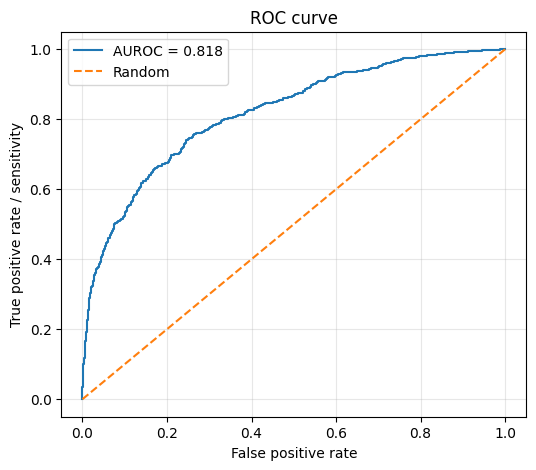

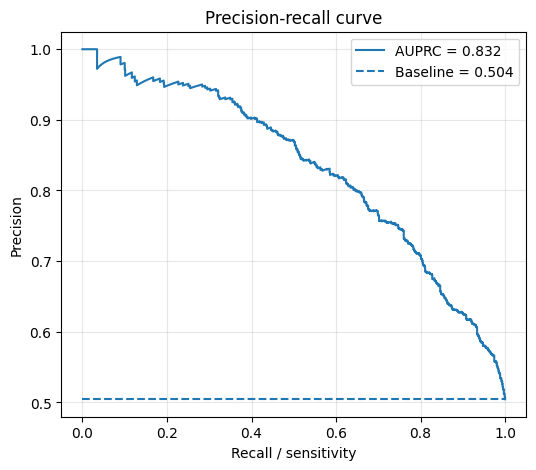

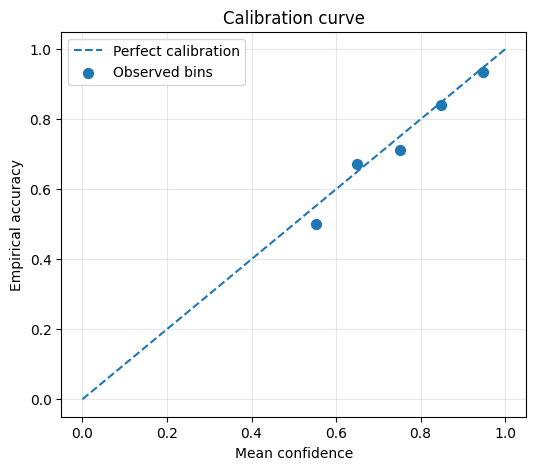

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,320,0.551636,0.500000,0.051636
6,7,0.6,0.7,408,0.650686,0.671569,0.020882
7,8,0.7,0.8,478,0.750217,0.711297,0.038920
8,9,0.8,0.9,436,0.847747,0.841743,0.006004
9,10,0.9,1.0,358,0.946852,0.935754,0.011098


In [ ]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)
